In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt

import tensorflow as tf
import torch
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model


In [ ]:
df = pd.read_csv("/content/Combined_Bestchannel_Data.csv")
print(df.shape)


(450, 20)


In [ ]:
df.head(15)

,Mean,Median,STD,Variance,Min,Max,Range,IQR,Kurtosis,Skewness,MAD,RMS,NumPeaks,Energy,ZCR,FFT_Mean,FFT_Std,PSD_Mean,PSD_Std,Class
0,34.714272,34.7230,20.043259,401.732227,0.005,69.433,69.428,34.70750,1.800548,0.000167,17.356164,40.084348,0,1.114285e+07,0.000072,0.038594,0.635629,31.384206,277.083614,Stand
1,35.213809,35.2060,20.329378,413.283618,0.001,70.412,70.411,35.20750,1.799680,-0.000052,17.606463,40.660019,2,1.162556e+07,0.000071,0.038642,0.640271,31.408350,277.296701,Stand
2,31.502505,31.5030,18.189516,330.858507,0.004,63.000,62.996,31.50200,1.799990,0.000002,15.751362,36.376015,21,8.440785e+06,0.000078,0.037809,0.601360,25.129497,221.859677,Stand
3,33.966201,33.9660,19.614020,384.709786,0.001,67.930,67.929,33.96900,1.800008,-0.000003,16.984973,39.221881,0,1.045159e+07,0.000074,0.038475,0.628299,30.154614,266.227335,Stand
4,34.990547,34.9890,17.322402,300.065619,4.994,64.984,59.990,30.00000,1.800124,-0.000049,14.999883,39.042976,1,9.143075e+06,0.000083,0.039755,0.675786,29.029960,256.297525,Stand
5,39.027600,39.0220,17.901140,320.450811,8.033,70.033,62.000,31.00575,1.799823,0.000129,15.502368,42.936612,0,1.142818e+07,0.000081,0.040789,0.735886,35.790671,315.989667,Stand
6,33.741582,33.7370,18.331360,336.038749,2.003,65.491,63.488,31.75150,1.800540,0.000538,15.872435,38.398960,0,9.354102e+06,0.000079,0.038921,0.640598,28.367137,250.445227,Stand
7,34.431215,34.4370,18.725906,350.659547,2.001,66.854,64.853,32.44100,1.799510,-0.000001,16.216970,39.193290,0,9.957091e+06,0.000077,0.038967,0.646804,29.483903,260.305517,Stand
8,32.789512,32.7960,17.764185,315.566274,2.001,63.552,61.551,30.74850,1.801043,-0.000811,15.381467,37.291648,0,8.549821e+06,0.000081,0.038859,0.632112,27.305975,241.076061,Stand
9,31.112216,31.1110,17.965862,322.772206,0.005,62.222,62.217,31.11625,1.799996,0.000008,15.557636,35.926171,8,7.946777e+06,0.000081,0.038576,0.604496,25.242988,222.861065,Stand


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Mean      450 non-null    float64
 1   Median    450 non-null    float64
 2   STD       450 non-null    float64
 3   Variance  450 non-null    float64
 4   Min       450 non-null    float64
 5   Max       450 non-null    float64
 6   Range     450 non-null    float64
 7   IQR       450 non-null    float64
 8   Kurtosis  450 non-null    float64
 9   Skewness  450 non-null    float64
 10  MAD       450 non-null    float64
 11  RMS       450 non-null    float64
 12  NumPeaks  450 non-null    int64  
 13  Energy    450 non-null    float64
 14  ZCR       450 non-null    float64
 15  FFT_Mean  450 non-null    float64
 16  FFT_Std   450 non-null    float64
 17  PSD_Mean  450 non-null    float64
 18  PSD_Std   450 non-null    float64
 19  Class     450 non-null    object 
dtypes: float64(18), int64(1), object

In [ ]:
df.describe()

,Mean,Median,STD,Variance,Min,Max,Range,IQR,Kurtosis,Skewness,MAD,RMS,NumPeaks,Energy,ZCR,FFT_Mean,FFT_Std,PSD_Mean,PSD_Std
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,4.500000e+02,450.000000,450.000000,450.000000,450.000000,450.000000
mean,19.944753,19.944808,10.787824,171.763182,1.244908,38.642665,37.397757,18.666434,2.330719,0.007127,9.339218,22.715226,106.737778,4.759563e+06,0.000657,0.033992,0.447855,14.968431,132.144218
std,14.469949,14.469822,7.450463,160.963416,4.742297,26.996313,25.785317,12.901038,3.305408,0.131849,6.451752,16.218580,355.818117,6.474869e+06,0.002717,0.010085,0.222622,18.115613,159.945514
min,-0.103812,-0.103500,0.007719,0.000060,-0.505600,-0.004501,0.130114,0.006108,1.797442,-0.868868,0.004809,0.030205,0.000000,5.693023e+00,0.000049,0.000064,0.000528,0.000018,0.000147
25%,7.287433,7.286500,4.061000,16.491722,0.004000,14.468250,14.052750,7.030625,1.799988,-0.000006,3.515666,8.375853,0.000000,1.010093e+05,0.000081,0.033686,0.291952,1.256067,11.074919
50%,25.751826,25.751500,14.435417,208.381272,0.008000,50.986500,49.990500,23.032500,1.800000,0.000004,12.500218,29.734403,3.000000,4.425852e+06,0.000088,0.037668,0.546063,16.688831,147.334613
75%,31.528460,31.528375,17.861524,319.034063,0.537500,62.876000,61.861250,30.934750,1.800027,0.000025,15.467294,36.375986,13.000000,8.232631e+06,0.000347,0.038580,0.607648,25.335760,223.680105
max,111.470567,111.470000,29.542474,872.757779,75.045000,147.880000,102.323000,51.166000,58.128025,1.587307,25.583314,113.437021,1732.000000,9.371734e+07,0.028921,0.059319,1.862774,252.251504,2227.175873


Class distribution (%):
 Class
Walk     41.777778
Stand    19.777778
Sit      19.555556
Lay      18.888889
Name: count, dtype: float64
Class imbalance ratio (minority/majority): 0.452


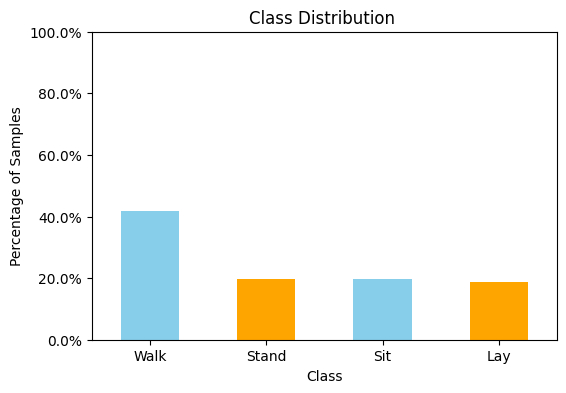

In [ ]:


# Check class imbalance
class_counts = df['Class'].value_counts()
total = class_counts.sum()

# Convert counts to percentages
class_percentages = (class_counts / total) * 100

print("Class distribution (%):\n", class_percentages)
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Class imbalance ratio (minority/majority): {imbalance_ratio:.3f}")

# Visualization
plt.figure(figsize=(6, 4))
class_percentages.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Class Distribution ')
plt.xlabel('Class')
plt.ylabel('Percentage of Samples')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
plt.show()

In [ ]:
mapping = {
    'Stand': 0,
    'Walk': 1,
    'Sit': 2,
    'Lay': 3
}

df['Class_encoded'] = df['Class'].map(mapping)

# Now check if any NaNs remain
if df['Class_encoded'].isna().any():
    print("Unmapped class names:", df.loc[df['Class_encoded'].isna(), 'Class'].unique())

print(df[['Class', 'Class_encoded']].head())

   Class  Class_encoded
0  Stand              0
1  Stand              0
2  Stand              0
3  Stand              0
4  Stand              0


In [ ]:
df.drop(columns=['Class'], inplace=True)

In [ ]:
label_col = 'Class_encoded'

X = df.drop(columns=[label_col])
y = df[label_col]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data only
scaler.fit(X_train)

# Transform both training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

1D CNN

In [ ]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# ✅ FIX INPUT SHAPE (MAIN SOLUTION)
X_train_cnn = np.array(X_train_cnn)

# Remove all extra dimensions (important)
X_train_cnn = np.squeeze(X_train_cnn)

# Ensure it becomes 3D: (samples, timesteps, 1)
if len(X_train_cnn.shape) == 2:
    X_train_cnn = np.expand_dims(X_train_cnn, axis=-1)

print("X_train_cnn shape:", X_train_cnn.shape)

input_shape = (X_train_cnn.shape[1], 1)

# ✅ Correct num_classes safely
y_train = np.array(y_train).reshape(-1,)
num_classes = len(np.unique(y_train))

inputs = layers.Input(shape=input_shape)

# 1D CNN
x = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

# Flatten
x = layers.Flatten()(x)

# Dense layers
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# Output
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Model
cnn_model = tf.keras.Model(inputs, outputs)

cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

cnn_model.summary()

# Train
history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=50,
    batch_size=8,
    #batch_size=16,
    #batch_size=32,
    validation_split=0.2,
    shuffle=True
)

X_train_cnn shape: (360, 19, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 19, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,452 (283.02 KB)

 Trainable params: 72,452 (283.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5660 - loss: 1.0077 - val_accuracy: 0.6528 - val_loss: 0.7782
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6076 - loss: 0.7490 - val_accuracy: 0.5278 - val_loss: 0.7181
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6076 - loss: 0.6845 - val_accuracy: 0.7083 - val_loss: 0.6648
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6458 - loss: 0.6912 - val_accuracy: 0.6528 - val_loss: 0.7009
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6389 - loss: 0.6646 - val_accuracy: 0.5694 - val_loss: 0.6651
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5938 - loss: 0.6614 - val_accuracy: 0.6528 - val_loss: 0.6397
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6493 - loss: 0.6317 - val_accuracy: 0.6528 - val_loss: 0.6581
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6840 - loss: 0.6297 - val_accuracy: 0.6528 - val_loss

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# Predict
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Core 4 Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("🔹 Accuracy :", accuracy)
print("🔹 Precision:", precision)
print("🔹 Recall   :", recall)
print("🔹 F1 Score :", f1)

# ✅ Detailed report (per class)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
🔹 Accuracy : 0.6555555555555556
🔹 Precision: 0.6015790984783232
🔹 Recall   : 0.6555555555555556
🔹 F1 Score : 0.59978982765868

Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.89      0.52        18
           1       1.00      1.00      1.00        38
           2       0.00      0.00      0.00        17
           3       0.56      0.29      0.38        17

    accuracy                           0.66        90
   macro avg       0.48      0.55      0.48        90
weighted avg       0.60      0.66      0.60        90

Confusion Matrix:

[[16  0  0  2]
 [ 0 38  0  0]
 [15  0  0  2]
 [12  0  0  5]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

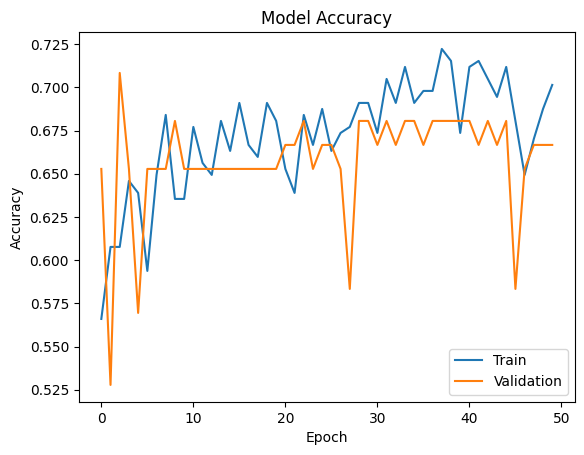

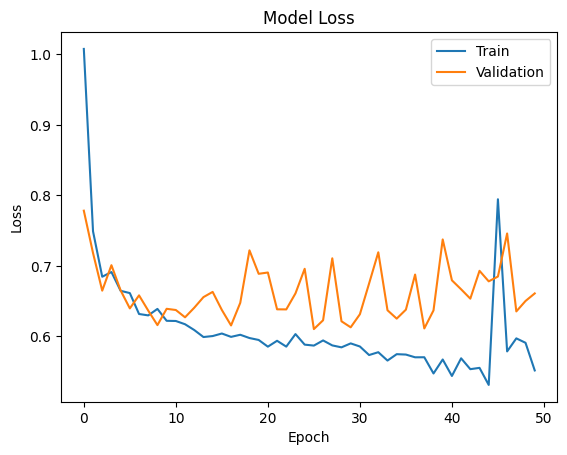

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

LSTM



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# ✅ FIX INPUT SHAPE PROPERLY
X_train_lstm = np.array(X_train_cnn)

# Remove extra dimensions
X_train_lstm = np.squeeze(X_train_lstm)

# Ensure 3D shape for LSTM: (samples, timesteps, features)
if len(X_train_lstm.shape) == 2:
    X_train_lstm = np.expand_dims(X_train_lstm, axis=-1)

print("X_train_lstm shape:", X_train_lstm.shape)

input_shape = (X_train_lstm.shape[1], 1)

# ✅ Fix labels
y_train = np.array(y_train).reshape(-1,)
num_classes = len(np.unique(y_train))

inputs = layers.Input(shape=input_shape)

# LSTM Layers
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inputs)
x = layers.BatchNormalization()(x)

x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.BatchNormalization()(x)

# Dense layers
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.4)(x)

# Output
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Model
lstm_model = tf.keras.Model(inputs, outputs)

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

lstm_model.summary()

# ✅ Train (NO CALLBACKS)
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=50,
    batch_size=8,
    #batch_size=16,
    #batch_size=32,
    validation_split=0.2,
    shuffle=True
)

X_train_lstm shape: (360, 19, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 19, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 19, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,612 (361.77 KB)

 Trainable params: 92,228 (360.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.5000 - loss: 1.2008 - val_accuracy: 0.5972 - val_loss: 1.1963
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6042 - loss: 0.8707 - val_accuracy: 0.5972 - val_loss: 1.1071
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6389 - loss: 0.8088 - val_accuracy: 0.6111 - val_loss: 1.0514
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6076 - loss: 0.7887 - val_accuracy: 0.6389 - val_loss: 0.9226
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6424 - loss: 0.7101 - val_accuracy: 0.6111 - val_loss: 0.8465
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6215 - loss: 0.7401 - val_accuracy: 0.6250 - val_loss: 0.7716
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6215 - loss: 0.6768 - val_accuracy: 0.6111 - val_loss: 0.7898
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6458 - loss: 0.6588 - val_accuracy: 0.6528 - v

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# ✅ Prepare test data (IMPORTANT: reshape like train)
X_test_lstm = np.expand_dims(X_test_cnn.squeeze(), axis=-1)

# Predict
y_pred_probs = lstm_model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("🔹 Accuracy :", round(accuracy, 4))
print("🔹 Precision:", round(precision, 4))
print("🔹 Recall   :", round(recall, 4))
print("🔹 F1 Score :", round(f1, 4))

# ✅ Detailed report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step
🔹 Accuracy : 0.6667
🔹 Precision: 0.6176
🔹 Recall   : 0.6667
🔹 F1 Score : 0.6075

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.94      0.55        18
           1       1.00      1.00      1.00        38
           2       0.00      0.00      0.00        17
           3       0.62      0.29      0.40        17

    accuracy                           0.67        90
   macro avg       0.50      0.56      0.49        90
weighted avg       0.62      0.67      0.61        90

Confusion Matrix:
 [[17  0  0  1]
 [ 0 38  0  0]
 [15  0  0  2]
 [12  0  0  5]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

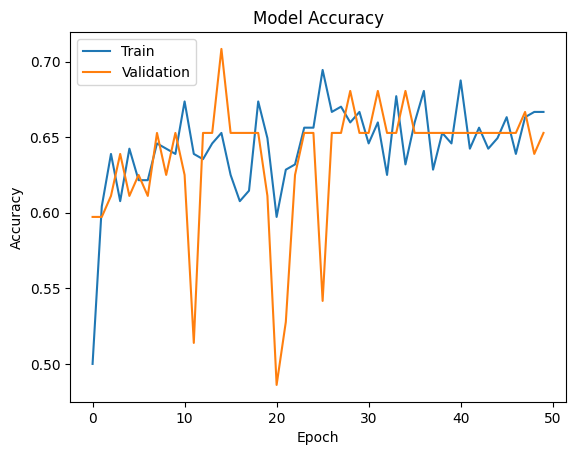

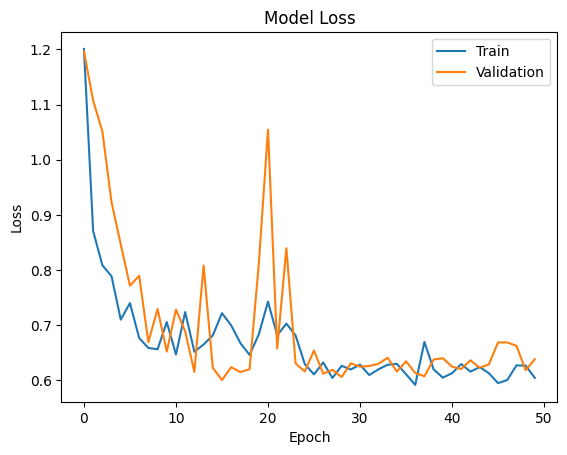

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

ROC Curve

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


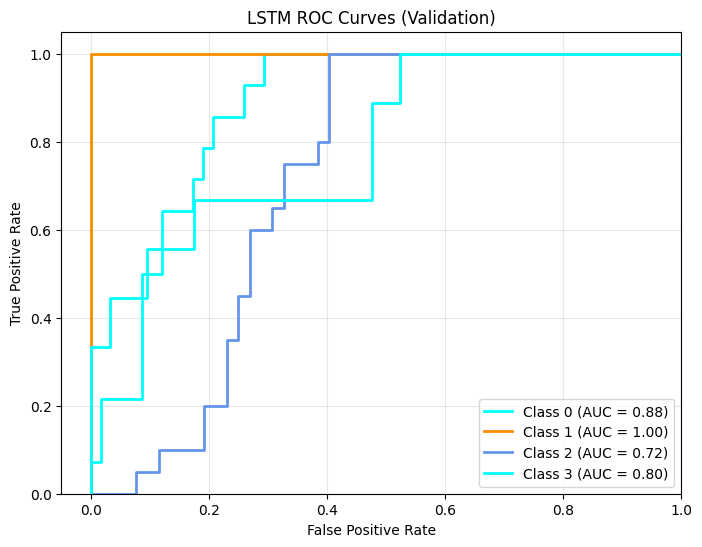

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Split to get val data (20% as in fit)
split_idx = int(0.8 * len(X_train_lstm))
X_val_lstm, y_val = X_train_lstm[split_idx:], y_train[split_idx:]

# Predict probabilities
y_pred_proba = lstm_model.predict(X_val_lstm)  # Shape: (n_val, num_classes)

# For binary (if num_classes==2): use class 1 probs
if num_classes == 2:
    y_pred_proba = y_pred_proba[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
else:
    # Multi-class one-vs-rest
    y_val_bin = label_binarize(y_val, classes=range(num_classes))
    plt.figure(figsize=(8, 6))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(num_classes), colors):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

#plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM ROC Curves (Validation)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()